In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


Column Name | Type	| Unit | Values	Description

age |	integer | years 	| Age of the patient

anaemia |	binary | 0 = No, 1 = Yes | Decrease of red blood cells or hemoglobin

creatinine_phosphokinase |	integer |	mcg/L |	Level of CPK enzyme in the blood

diabetes |	binary | 0 = No, 1 = Yes |	Whether the patient has diabetes

ejection_fraction |	integer | percentage |	Percentage of blood leaving the heart at each contraction

high_blood_pressure |	binary | 0 = No, 1 = Yes |	Whether the patient has hypertension

platelets |	float |	kiloplatelets/mL |	Platelet count in the blood

serum_creatinine |	float |	mg/dL |	Level of serum creatinine in the blood

serum_sodium |	integer |	mEq/L | Level of serum sodium in the blood

sex	| binary  0 = Female, 1 = Male | Gender of the patient

smoking | binary |	0 = No, 1 = Yes |	Smoking habit

time |	integer |	days |	Follow-up period

DEATH_EVENT | binary | 0 = No, 1 = Yes |Target variable — whether the patient died during the follow-up period

In [5]:
df.DEATH_EVENT.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

The label class has an imbalance distribution in favour of no death class. A stratified train-test spliting would be done

In [7]:
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

# Preprocessing

- Change anaemia, diabetes, high_blood_pressure, sex and smoke to string label and then perform one-hot encoding on them to give equal weight to their categories
- use to_categorical() function to perform one_hot encoding for death event to be able to use **categorica_croossentropy** loss. However, we can leave the label as it is if we want to use **sparse_categorical_crossentropy**

In [10]:
label = {0: "No", 1: "Yes"}
label2 = {0: "Female", 1: "Male"}
df["anaemia"] = df["anaemia"].map(label)
df["diabetes"] = df["diabetes"].map(label)
df["high_blood_pressure"] = df["high_blood_pressure"].map(label)
df["smoking"] = df["smoking"].map(label)
df["sex"] = df["sex"].map(label2)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,No,582,No,20,Yes,265000.00,1.9,130,Male,No,4,1
1,55.0,No,7861,No,38,No,263358.03,1.1,136,Male,No,6,1
2,65.0,No,146,No,20,No,162000.00,1.3,129,Male,Yes,7,1
3,50.0,Yes,111,No,20,No,210000.00,1.9,137,Male,No,7,1
4,65.0,Yes,160,Yes,20,No,327000.00,2.7,116,Female,No,8,1


In [11]:
# perform one-hot encoding on the caregorical data
df = pd.get_dummies(df, columns = ["anaemia", "diabetes", "high_blood_pressure", "smoking", "sex"], drop_first=False)
df.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,anaemia_No,anaemia_Yes,diabetes_No,diabetes_Yes,high_blood_pressure_No,high_blood_pressure_Yes,smoking_No,smoking_Yes,sex_Female,sex_Male
0,75.0,582,20,265000.00,1.9,130,4,1,True,False,True,False,False,True,True,False,False,True
1,55.0,7861,38,263358.03,1.1,136,6,1,True,False,True,False,True,False,True,False,False,True
2,65.0,146,20,162000.00,1.3,129,7,1,True,False,True,False,True,False,False,True,False,True
3,50.0,111,20,210000.00,1.9,137,7,1,False,True,True,False,True,False,True,False,False,True
4,65.0,160,20,327000.00,2.7,116,8,1,False,True,False,True,True,False,True,False,True,False


# Split the Data into X and y

In [13]:
X = df.drop(columns = "DEATH_EVENT")
X.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia_No,anaemia_Yes,diabetes_No,diabetes_Yes,high_blood_pressure_No,high_blood_pressure_Yes,smoking_No,smoking_Yes,sex_Female,sex_Male
0,75.0,582,20,265000.00,1.9,130,4,True,False,True,False,False,True,True,False,False,True
1,55.0,7861,38,263358.03,1.1,136,6,True,False,True,False,True,False,True,False,False,True
2,65.0,146,20,162000.00,1.3,129,7,True,False,True,False,True,False,False,True,False,True
3,50.0,111,20,210000.00,1.9,137,7,False,True,True,False,True,False,True,False,False,True
4,65.0,160,20,327000.00,2.7,116,8,False,True,False,True,True,False,True,False,True,False


In [14]:
y = df["DEATH_EVENT"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: DEATH_EVENT, dtype: int64

In [15]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
y_cc = to_categorical(y).astype("int64")

# Split the Data into Test and Train

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_cc, test_size = 0.3, stratify = y_cc, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 17), (90, 17), (209, 2), (90, 2))

# Standardise X

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Build a Dummy Model for Baseline  Performance

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score 
cls_dummy = DummyClassifier() # you can also use median depending on the dataset
cls_dummy.fit(X_train, y_train)
y_pred_dummy = cls_dummy.predict(X_test)
y_pred_dummy = np.argmax(y_pred_dummy, axis = 1) # changes y_pred from one-hot encoding
y_test_dummy = np.argmax(y_test, axis = 1)
baseline_report = classification_report(y_test_dummy, y_pred_dummy)
baseline_roc_auc_score = roc_auc_score(y_test_dummy, y_pred_dummy)
baseline_cm = confusion_matrix(y_test_dummy, y_pred_dummy)
print("baseline_report is: ", baseline_report)
print("baseline_roc_auc_score is: ", baseline_roc_auc_score)
print("baseline_cm is: ", baseline_cm)

baseline_report is:                precision    recall  f1-score   support

           0       0.68      1.00      0.81        61
           1       0.00      0.00      0.00        29

    accuracy                           0.68        90
   macro avg       0.34      0.50      0.40        90
weighted avg       0.46      0.68      0.55        90

baseline_roc_auc_score is:  0.5
baseline_cm is:  [[61  0]
 [29  0]]


C:\Users\emper\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\emper\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\emper\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Build the FeedForward Deep Learning Model

In [30]:
# import the model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras.optimizers import Adam

In [61]:
def build_ffnmodel(layer1_neurons, layer2_neurons, layer3_neurons, learning_rate): 
    ffn_model = Sequential()
    # Add the import layer
    ffn_model.add(InputLayer(shape=(X_train.shape[1],)))
    # add the first hidden layer
    ffn_model.add(Dense(layer1_neurons, activation="relu"))
    # Add a second hidden layer
    ffn_model.add(Dense(layer2_neurons, activation="relu"))
    # Add a third hidden layer
    ffn_model.add(Dense(layer3_neurons, activation="relu"))
    # Add the output layer
    ffn_model.add(Dense(2, activation="softmax"))
    opt = Adam(learning_rate=learning_rate)
    ffn_model.compile(loss = "categorical_crossentropy", metrics=["accuracy"], optimizer=opt)
    return ffn_model

ffn_model = build_ffnmodel(20, 10, 5, 0.01)
ffn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 20)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637 (2.49 KB)

 Trainable params: 637 (2.49 KB)

 Non-trainable params: 0 (0.00 B)

# Fit the Model on the Training Dataset

In [64]:
# Fit the model to the training dataset
history_1 = ffn_model.fit(X_train,y_train, epochs=20, batch_size=4, validation_split=0.2, verbose=1)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6139 - loss: 0.6584 - val_accuracy: 0.7619 - val_loss: 0.4792
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7522 - loss: 0.4695 - val_accuracy: 0.7619 - val_loss: 0.4617
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8596 - loss: 0.3537 - val_accuracy: 0.7619 - val_loss: 0.4722
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8466 - loss: 0.3481 - val_accuracy: 0.8333 - val_loss: 0.4829
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9179 - loss: 0.2780 - val_accuracy: 0.7381 - val_loss: 0.5092
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9684 - loss: 0.1715 - val_accuracy: 0.7143 - val_loss: 0.5605
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9119 - loss: 0.2037 - val_accuracy: 0.7619 - val_loss: 0.5745
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9315 - loss: 0.2053 - val_accuracy: 0.8333 - val_loss

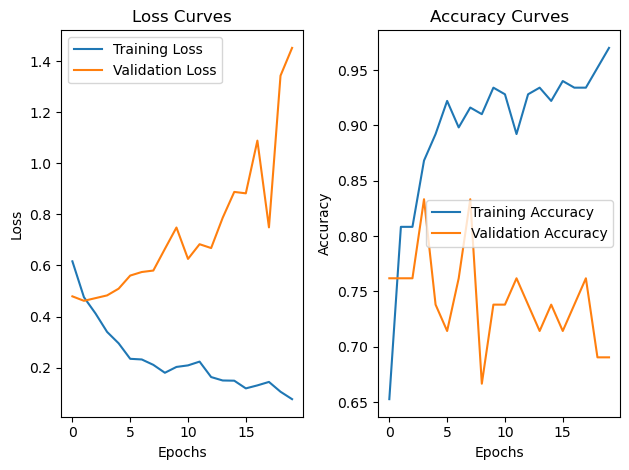

In [66]:
def plot_curves(history):
    # Plot training loss and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training accuracy and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
    return
plot_curves(history_1)

# Evaluate the Model 

In [68]:
loss, acc = ffn_model.evaluate(X_test,y_test, verbose=0)
print("categorical_crossentropy loss is: ", loss)
print("accuracy is: ", acc)

categorical_crossentropy loss is:  1.4003775119781494
accuracy is:  0.7555555701255798


# Hyperparameter Tuning 

In [79]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping
# Define parameters
#parameters = {"batch_size": sp_randint(2,10),
#              "epochs": sp_randint(10,40)}
parameters = {
    "model__layer1_neurons": [8, 16, 32], # note the use of two underscores(__) to route the build_ffnmodel parameters
    "model__layer2_neurons": [8, 16, 32],
    "model__layer3_neurons": [8, 16, 32],
    "model__learning_rate": [0.01, 0.1, 0.05],
    "batch_size": [16, 32, 64],
    "epochs": [10, 20, 30], 
    }
stop = EarlyStopping(monitor="val_loss", mode="min", verbose=1, patience=5)
# Wrap the model 
ffn_model = KerasClassifier(model=build_ffnmodel, verbose=0) # Note that we passed build_ffn model here
# Instantiate the RandomizedSearch() 
ffn_grid = RandomizedSearchCV(ffn_model, parameters,n_iter=5, random_state=100, cv=3, scoring="accuracy")
history_2 = ffn_grid.fit(X_train, y_train, verbose=1, validation_split=0.2, callbacks=[stop])
best_estimator = ffn_grid.best_estimator_
best_model = best_estimator.model_ # the model was defined earlier at the KerasClassifier wrapper
# Now evaluate the model
loss, acc = best_model.evaluate(X_test, y_test, verbose=0) 
print("loss is: ", loss)
print("accuracy is: ", acc)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 708ms/step - accuracy: 0.5695 - loss: 0.6996 - val_accuracy: 0.7857 - val_loss: 0.7118
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6616 - loss: 0.8872 - val_accuracy: 0.8214 - val_loss: 0.4424
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7513 - loss: 0.5740 - val_accuracy: 0.6071 - val_loss: 0.6370
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.6416 - loss: 0.6250 - val_accuracy: 0.8571 - val_loss: 0.4544
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7829 - loss: 0.4796 - val_accuracy: 0.8929 - val_loss: 0.3609
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7957 - loss: 0.4668 - val_accuracy: 0.8929 - val_loss: 0.3670
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8226 - loss: 0.4498 - val_accuracy: 0.9286 - val_loss: 0.3446
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8474 - loss: 0.3953 - val_accuracy: 0.8929 - val_loss:

# Generate Classification report and Confusion Matrix

In [82]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score 
# Get y_pred
y_pred = best_model.predict(X_test)
y_pred = np.argmax(y_pred, axis = 1) # changes y_pred from one-hot encoding
y_test_label = np.argmax(y_test, axis = 1) # changes y_pred from one-hot encoding
reports = classification_report(y_test_label, y_pred)
cm = confusion_matrix(y_test_label, y_pred)
print(reports)
cm = confusion_matrix(y_test_label, y_pred)
cm

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step 
              precision    recall  f1-score   support

           0       0.89      0.79      0.83        61
           1       0.64      0.79      0.71        29

    accuracy                           0.79        90
   macro avg       0.76      0.79      0.77        90
weighted avg       0.81      0.79      0.79        90



array([[48, 13],
       [ 6, 23]], dtype=int64)

In [84]:
from sklearn.metrics import roc_auc_score 

roc_auc = roc_auc_score(y_test_label, y_pred)
roc_auc

0.7899943470887507

In [89]:
results_tabel ={"Metrics": ["Accuracy", "Precision", "Recal", "F1-Score", "ROC-AUC"],
 "Values":[0.79, 0.64, 0.79, 0.71, 0.79]}
results_tabel = pd.DataFrame(results_tabel)
results_tabel

,metrics,Values
0,Accuracy,0.79
1,Precision,0.64
2,Recal,0.79
3,F1-Score,0.71
4,ROC-AUC,0.79


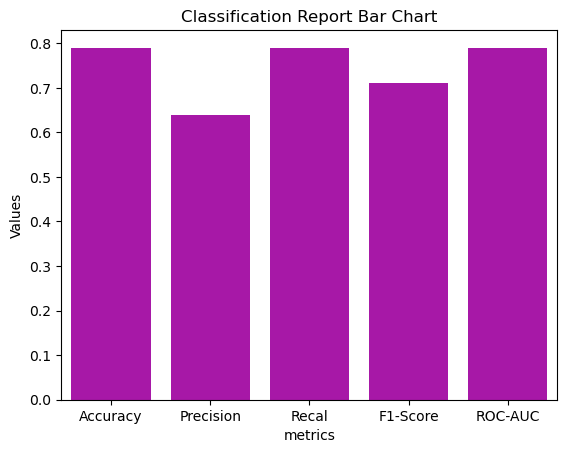

In [100]:
sns.barplot(results_tabel, x="metrics", y="Values", color = "m")
plt.title("Classification Report Bar Chart")
plt.show()

The model correctly predicted 48 no death events out of 61 events and incorrectly predicted the remaining 13 no death events as death events. Also, it correctly predicted 23 death events out of 29 events while 6 death events were incoreectly predicted as no death events.For predicting death, it achieved a precision of 64%, recall (sensitivity) of 79%, and an F1-score of 71%. This means that the model correctly identified approximately 79% of patients who actually died, while 21% of actual deaths were missed. The precision of 64% indicates that 64% of patients predicted to die actually died. An ROC-AUC of 0.79 indicates that the model has reasonably good ability to discriminate between patients who died and those who did not. 